In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 读取数据集

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
feature_names = list(housing.feature_names)
target_name = housing.target_names[0]

print("样本数量:", df.shape[0])
print("特征数量:", len(feature_names))
print("目标变量:", target_name)
display(df.head())
display(df.describe().T[["mean", "std", "min", "max"]])

样本数量: 20640
特征数量: 8
目标变量: MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,mean,std,min,max
MedInc,3.870671,1.899822,0.499900,15.000100
HouseAge,28.639486,12.585558,1.000000,52.000000
AveRooms,5.429000,2.474173,0.846154,141.909091
AveBedrms,1.096675,0.473911,0.333333,34.066667
Population,1425.476744,1132.462122,3.000000,35682.000000
AveOccup,3.070655,10.386050,0.692308,1243.333333
Latitude,35.631861,2.135952,32.540000,41.950000
Longitude,-119.569704,2.003532,-124.350000,-114.310000
MedHouseVal,2.068558,1.153956,0.149990,5.000010


## 2. 简单数据观察

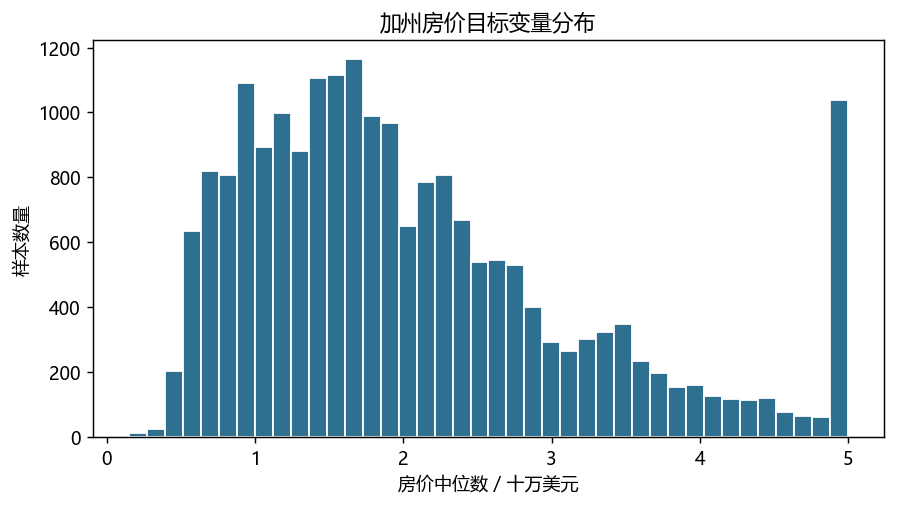

In [4]:
plt.figure(figsize=(7, 4), dpi=130)
plt.hist(df[target_name], bins=40, color="#2f6f8f", edgecolor="white")
plt.xlabel("房价中位数 / 十万美元")
plt.ylabel("样本数量")
plt.title("加州房价目标变量分布")
plt.tight_layout()
plt.show()

## 3. 划分训练集和测试集

梯度量级会受到特征单位影响，因此在建模前使用标准化。标准化器只在训练集上拟合，再作用到测试集。

In [5]:
X = df[feature_names].to_numpy(dtype=float)
y = df[target_name].to_numpy(dtype=float)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("训练集:", X_train.shape)
print("测试集:", X_test.shape)

训练集: (16512, 8)
测试集: (4128, 8)


## 4. 多元线性回归类

采用闭式解：

$$\theta=(X_b^TX_b)^+X_b^Ty$$

其中 $X_b$ 是添加截距列后的设计矩阵，$+$ 表示 Moore-Penrose 伪逆。使用伪逆可以在矩阵接近奇异时保持数值稳定。

In [6]:
class MyLinearRegression:
    """
    自定义多元线性回归类。

    类的运行流程：
    1. fit 中将 X/y 转成 ndarray，并给 X 添加截距列；
    2. 使用正规方程的伪逆闭式解求参数 theta；
    3. 保存 intercept_、coef_、theta_，predict 直接使用这些参数；
    4. score 使用 R^2 评价模型拟合效果。

    重要变量：
    - X_b：fit/predict 内部的局部变量，表示添加截距列后的特征矩阵；
    - theta_：实例属性，第 0 项是截距，其余项是各特征权重；
    - coef_ / intercept_：从 theta_ 拆分出来，便于查看模型参数。
    """

    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.theta_ = None
        self.intercept_ = None
        self.coef_ = None

    def _add_intercept(self, X):
        """
        运行流程：
        1. 接收二维特征矩阵 X；
        2. 如果 fit_intercept=True，则在最左侧拼接全 1 列；
        3. 返回可直接用于矩阵乘法的设计矩阵。

        关键局部变量：ones 是截距列，只在本函数内部使用。
        """
        X = np.asarray(X, dtype=float)
        if not self.fit_intercept:
            return X
        ones = np.ones((X.shape[0], 1))
        return np.c_[ones, X]

    def fit(self, X, y):
        """
        运行流程：
        1. 将输入转换为 numpy 数组；
        2. 调用 _add_intercept 得到 X_b；
        3. 用 pinv(X_b.T @ X_b) @ X_b.T @ y 求闭式解；
        4. 将截距和系数保存到实例属性中。

        依赖关系：predict 和 score 都依赖本函数产生的 theta_。
        """
        X_b = self._add_intercept(X)
        y = np.asarray(y, dtype=float)
        self.theta_ = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

        if self.fit_intercept:
            self.intercept_ = self.theta_[0]
            self.coef_ = self.theta_[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = self.theta_
        return self

    def predict(self, X):
        """
        运行流程：
        1. 检查模型是否已经 fit；
        2. 对输入 X 添加截距列；
        3. 返回 X_b @ theta_ 得到的预测值。
        """
        if self.theta_ is None:
            raise RuntimeError("模型尚未训练，请先调用 fit。")
        X_b = self._add_intercept(X)
        return X_b @ self.theta_

    def score(self, X, y):
        """
        运行流程：
        1. 调用 predict 得到预测值；
        2. 计算 R^2 = 1 - SSE / SST；
        3. 返回越接近 1 越好的拟合分数。
        """
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return 1 - sse / sst


def regression_metrics(y_true, y_pred):
    """
    运行流程：
    1. 根据真实值和预测值计算误差 residual；
    2. 输出 MAE、RMSE、R^2 三个常用回归指标。

    关键变量：residual 是局部误差向量，不改变模型参数。
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_true - y_pred
    mae = np.mean(np.abs(residual))
    rmse = np.sqrt(np.mean(residual ** 2))
    sse = np.sum(residual ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - sse / sst
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

## 5. 训练模型并评价

In [7]:
linear_model = MyLinearRegression()
linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

metrics = pd.DataFrame(
    [regression_metrics(y_train, train_pred), regression_metrics(y_test, test_pred)],
    index=["训练集", "测试集"],
)
display(metrics.round(4))

print("截距:", round(linear_model.intercept_, 4))

,MAE,RMSE,R2
训练集,0.5286,0.7197,0.6126
测试集,0.5332,0.7456,0.5758


截距: 2.0719


## 6. 查看模型系数

由于特征已标准化，系数绝对值越大，说明该特征在这个线性模型中的影响越明显。

In [8]:
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient_after_standardization": linear_model.coef_,
})
coef_table = coef_table.sort_values(
    "coefficient_after_standardization",
    key=lambda col: col.abs(),
    ascending=False,
)
display(coef_table.round(4))

,feature,coefficient_after_standardization
6,Latitude,-0.8969
7,Longitude,-0.8698
0,MedInc,0.8544
3,AveBedrms,0.3393
2,AveRooms,-0.2944
1,HouseAge,0.1225
5,AveOccup,-0.0408
4,Population,-0.0023


## 7. 输出预测结果

In [9]:
prediction_result = pd.DataFrame({
    "actual_MedHouseVal": y_test[:12],
    "predicted_MedHouseVal": test_pred[:12],
})
prediction_result["absolute_error"] = (
    prediction_result["actual_MedHouseVal"] - prediction_result["predicted_MedHouseVal"]
).abs()
display(prediction_result.round(4))

,actual_MedHouseVal,predicted_MedHouseVal,absolute_error
0,0.477,0.7191,0.2421
1,0.458,1.7640,1.3060
2,5.000,2.7097,2.2904
3,2.186,2.8389,0.6529
4,2.780,2.6047,0.1753
5,1.587,2.0118,0.4248
6,1.982,2.6455,0.6635
7,1.575,2.1688,0.5938
8,3.400,2.7407,0.6593
9,4.466,3.9156,0.5504


## 8. 可视化预测效果

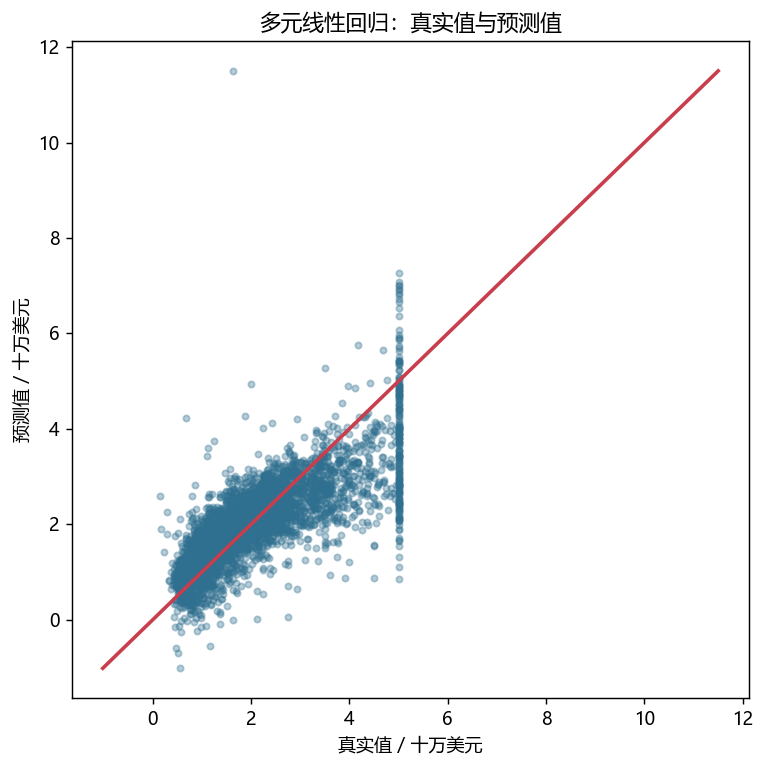

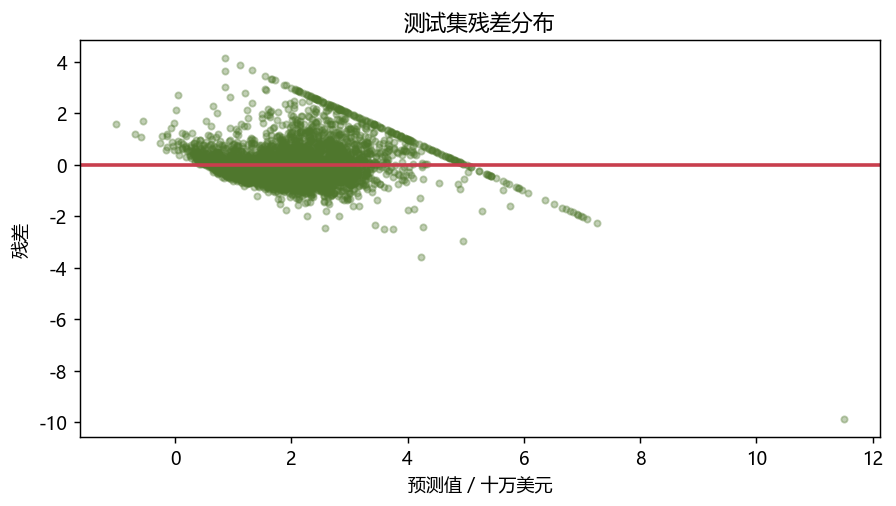

In [10]:
plt.figure(figsize=(6, 6), dpi=130)
plt.scatter(y_test, test_pred, s=12, alpha=0.35, color="#2f6f8f")
low = min(y_test.min(), test_pred.min())
high = max(y_test.max(), test_pred.max())
plt.plot([low, high], [low, high], color="#c83e4d", linewidth=2)
plt.xlabel("真实值 / 十万美元")
plt.ylabel("预测值 / 十万美元")
plt.title("多元线性回归：真实值与预测值")
plt.tight_layout()
plt.show()

residuals = y_test - test_pred
plt.figure(figsize=(7, 4), dpi=130)
plt.scatter(test_pred, residuals, s=12, alpha=0.35, color="#4f772d")
plt.axhline(0, color="#c83e4d", linewidth=2)
plt.xlabel("预测值 / 十万美元")
plt.ylabel("残差")
plt.title("测试集残差分布")
plt.tight_layout()
plt.show()